# 02 — Modèle final v4 : construction, formules et validation
Ce notebook charge les données, calcule les ratings, entraîne le **modèle final** et mesure sa qualité sur le **test intouché 2021/22 → 2025/26**.
La méthode est détaillée dans `docs/methodologie.md`.

| Étape | Contenu |
|---|---|
| Données | Dataset public xgabora (5 grands championnats, 2005 → aujourd'hui), mis à jour régulièrement |
| Ratings | ClubElo · pi-ratings (Constantinou & Fenton 2013) · ratings de buts GAS (Koopman & Lit 2019) |
| 1X2 | Régression logistique multinomiale, pondération temporelle (demi-vie 4 saisons) |
| Buts | 2 régressions de Poisson + correction Dixon-Coles (ρ) → grille des scores → tous les marchés |

In [1]:
# ── Installation : fonctionne dans Colab (clone le dépôt) comme en local (depuis le dossier notebooks/) ──
import os, sys
DEPOT = "https://github.com/abdelkbir1243/football-prediction-stat.git"   # ← adapter si le dépôt a un autre nom
if os.path.exists("../footpred"):
    os.chdir("..")
elif not os.path.exists("footpred"):
    os.system(f"git clone -q {DEPOT}"); os.chdir("football-prediction-stat")
    os.system("pip -q install -r requirements.txt")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from footpred import preparer, labo, journal, config
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

## 1. Données, ratings et modèle final (≈ 30 s)

In [2]:
pred = preparer()                       # télécharge (ou relit data/Matches.csv), calcule les variables, entraîne
d = pred.d
print(f"Données au {d.date_max.date()} · {len(d.X):,} matchs utilisables · saisons {d.X.Season.min()}/{d.X.Season.min()+1-2000:02d} → {d.X.Season.max()}/{d.X.Season.max()+1-2000:02d}")
print(f"Correction Dixon-Coles ρ = {pred.modele.buts.rho:+.3f} · part des buts en 1re mi-temps k = {pred.modele.buts.k_ht:.3f}")

Données au 2026-09-03 · 36,208 matchs utilisables · saisons 2005/06 → 2026/27
Correction Dixon-Coles ρ = -0.055 · part des buts en 1re mi-temps k = 0.439


## 2. Les formules du modèle
- **1X2** : z1 = Σ coef × variable (1re colonne), z2 (2e colonne) ; P(X) = 1 / (1 + e^z1 + e^z2), P(1) = e^z1 · P(X), P(2) = e^z2 · P(X)
- **Buts** : λ_dom = exp(Σ coef × variable), λ_ext idem ; P(i-j) = Poisson(i; λ_dom) · Poisson(j; λ_ext) · τ(i, j) (Dixon-Coles)

In [3]:
pred.formules().round(3)

,log[P(1)/P(X)],log[P(2)/P(X)],log λ_dom,log λ_ext
constante,0.070,-0.046,0.232,0.134
dElo,-0.017,-0.234,0.051,-0.084
absElo,0.097,0.076,-0.006,0.005
dQ,0.290,-0.142,0.096,-0.103
Otot,0.035,-0.016,0.044,0.032
pi_diff,0.092,-0.374,-0.006,-0.174
pi_diff_avg,-0.181,0.370,0.015,0.207
lg_SP1,-0.038,-0.079,-0.046,-0.056
lg_I1,-0.159,-0.046,-0.087,-0.032
lg_D1,-0.125,-0.050,0.004,-0.015


## 3. Validation walk-forward sur le test 2021-2026 (≈ 1 min)
Chaque saison est prédite par un modèle entraîné **uniquement** sur les saisons précédentes. Références : fréquences (aucune information), Elo seul (naïf), v3, cotes (externe).

/tmp/claude-0/-home-claude/75abb860-c445-5888-96a1-2e500f7f5c5d/scratchpad/repo/footpred/labo.py:147: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax[1].plot(g.p, g.o, "-o", lw=2, ms=6, color=COUL[nom], mec="white", mew=1.5, label=nom, ls="--" if nom == "Cotes" else "-")
/tmp/claude-0/-home-claude/75abb860-c445-5888-96a1-2e500f7f5c5d/scratchpad/repo/footpred/labo.py:147: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax[1].plot(g.p, g.o, "-o", lw=2, ms=6, color=COUL[nom], mec="white", mew=1.5, label=nom, ls="--" if nom == "Cotes" else "-")



■ 1X2


,matchs,log loss,RPS,Brier,ECE,bon résultat,skill vs fréquences
Fréquences,8821,1.0737,0.2300,0.6497,0.0103,0.4351,0.0000
Elo seul,8821,0.9864,0.2001,0.5882,0.0129,0.5242,0.0814
v3,8821,0.9823,0.1990,0.5854,0.0134,0.5286,0.0851
v4,8821,0.9818,0.1989,0.5849,0.0113,0.5257,0.0856
Cotes,8821,0.9722,0.1957,0.5783,0.0149,0.5366,0.0946



■ tests


,Δ log loss ×1e3,IC bas,IC haut,significatif
comparaison,,,,
v4 − v3,-0.5222,-1.6984,0.6891,False
v4 − Elo seul,-4.5482,-6.8311,-2.2052,True
v4 − Cotes,9.6381,6.7614,12.3175,True
v4 − v3 (score exact),-5.1660,-7.5309,-2.7598,True
"v4 − v3 (over 2,5)",-4.2350,-6.0047,-2.4761,True


...

,LL score exact,"LL over 2,5",LL BTTS,buts prévus/match
v3,2.9119,0.6802,0.6857,2.8050
v4,2.9067,0.6759,0.6839,2.8078
Cotes,NaN,0.6717,NaN,NaN
Réel,NaN,NaN,NaN,2.8084



■ par_ligue


,Elo seul,v3,v4,Cotes
Division,,,,
Bundesliga,0.9906,0.9866,0.9862,0.9763
Liga,0.9828,0.9787,0.9770,0.9675
Ligue 1,1.0006,0.9952,0.9942,0.9837
Premier League,0.9794,0.9746,0.9737,0.9606
Serie A,0.9809,0.9788,0.9801,0.9750



■ par_saison


,Elo seul,v3,v4,Cotes
Season,,,,
2021,0.9903,0.9886,0.9862,0.9778
2022,0.9867,0.9832,0.9878,0.9805
2023,0.9719,0.9679,0.9664,0.9567
2024,0.9855,0.9806,0.9782,0.9650
2025,0.9972,0.9911,0.9902,0.9802


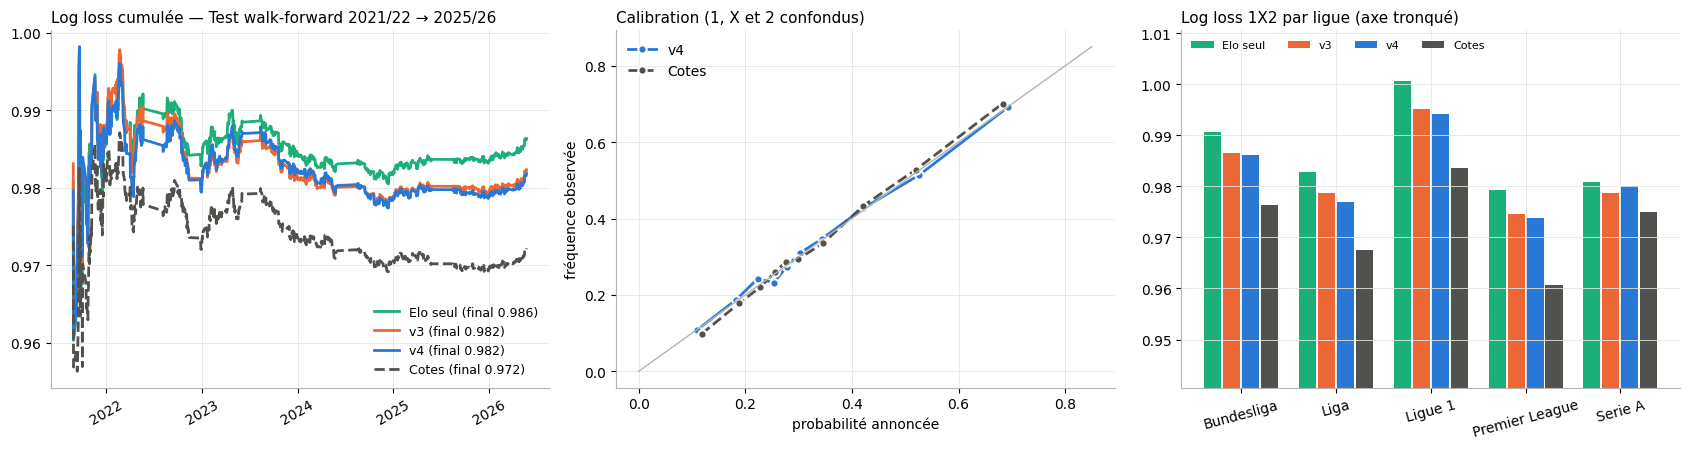

In [4]:
val = labo.validation(d)
labo.afficher(val)
pred.calibrer_fiabilite(val["_pred"][["P1", "PX", "P2"]].values, val["_pred"].y.values)   # indice de fiabilité
plt.show()

## 4. Simulation d'un match
`pred.simulation(dom, ext, elo_dom=None, elo_ext=None, cotes=None)` — noms d'équipes tels qu'ils apparaissent dans le dataset (un nom proche est suggéré en cas d'erreur).

In [5]:
r = pred.simulation("Barcelona", "Real Madrid")

SIMULATION MATHÉMATIQUE v4 : Barcelona – Real Madrid   (Liga)
ΔElo +0.37 · ΔQ +0.03 · pi +0.37 · GAS : buts « bruts » 2.07 – 1.35 · données au 2026-08-31

  ► Victoire Barcelona               50.3%
  ► Match nul                        25.3%
  ► Victoire Real Madrid             24.4%

  Buts attendus : Barcelona 1.88 · Real Madrid 1.27   ·   Monte-Carlo (100,000) : 1 50.8% · X 23.4% · 2 25.7%

  Marché                              Probabilité   Cote juste (1/p)
  Victoire Barcelona                     50.3%        1.99
  Match nul                              25.3%        3.95
  Victoire Real Madrid                   24.4%        4.10
  Plus de 1,5 but                        82.8%        1.21
  Plus de 2,5 buts                       60.9%        1.64
  Plus de 3,5 buts                       38.6%        2.59
  Les deux équipes marquent              61.5%        1.63
  But en 1re mi-temps                    74.9%        1.34
  Cage inviolée Barcelona                28.0%        3.57
  Ca

In [6]:
r = pred.simulation("Paris SG", "Marseille", cotes=(1.45, 4.60, 6.50))   # cotes fictives : comparaison au marché

SIMULATION MATHÉMATIQUE v4 : Paris SG – Marseille   (Ligue 1)
ΔElo +1.70 · ΔQ -0.36 · pi +0.46 · GAS : buts « bruts » 2.36 – 1.14 · données au 2026-08-30

  ► Victoire Paris SG                56.3%
  ► Match nul                        23.4%
  ► Victoire Marseille               20.3%

  Buts attendus : Paris SG 2.04 · Marseille 1.19   ·   Monte-Carlo (100,000) : 1 56.6% · X 21.9% · 2 21.4%

  Marché                              Probabilité   Cote juste (1/p)
  Victoire Paris SG                      56.3%        1.78
  Match nul                              23.4%        4.28
  Victoire Marseille                     20.3%        4.92
  Plus de 1,5 but                        83.7%        1.19
  Plus de 2,5 buts                       62.5%        1.60
  Plus de 3,5 buts                       40.3%        2.48
  Les deux équipes marquent              60.9%        1.64
  But en 1re mi-temps                    75.7%        1.32
  Cage inviolée Paris SG                 30.5%        3.28
  Cage 